In [2]:
from google.colab import drive
import os

# 1. Ngắt kết nối Drive hiện tại (nếu có)
drive.flush_and_unmount()

# 2. Xóa sạch thư mục mount cũ để đảm bảo không bị lỗi "Already contains files"
!rm -rf /content/drive

# 3. Kết nối lại
drive.mount('/content/drive')

# 4. Kiểm tra lại đường dẫn
os.chdir('/content/drive/MyDrive/PROJECT')
print("Đã kết nối lại thành công tới:", os.getcwd())

Drive not mounted, so nothing to flush and unmount.
Mounted at /content/drive
Đã kết nối lại thành công tới: /content/drive/MyDrive/PROJECT


# Notebook 5: MiniLM + FP-Max Controlled Hybrid

Notebook này kiểm tra việc kết hợp MiniLM embedding với đặc trưng FP-Max theo hướng có kiểm soát.

Ở Notebook 3, FP-Max đã được khai thác trên transaction nhị phân tạo từ `lexical_text`, sau đó chuyển các pattern phổ biến tối đại thành đặc trưng nhị phân. Ở Notebook 4, mô hình MiniLM semantic baseline đã được chọn là MiniLM + UMAP + K-Means với `k = 6`.

Notebook 5 tiếp tục từ hai kết quả đó để kiểm tra xem FP-Max có thể bổ sung tín hiệu lexical cho MiniLM hay không.

Điểm quan trọng:

- FP-Max không được chạy trực tiếp trên MiniLM embedding.
- FP-Max chỉ được khai thác từ transaction nhị phân của nhánh lexical.
- MiniLM embedding và FP-Max binary features thuộc hai không gian biểu diễn khác nhau, nên cần chuẩn hóa trước khi ghép.
- FP-Max được ghép vào MiniLM bằng hệ số `alpha` nhỏ để tránh làm méo không gian ngữ nghĩa của MiniLM.

Công thức hybrid:

`X_hybrid = concat([normalize(X_minilm), alpha * normalize(X_fpmax)])`

Trong đó:

- `X_minilm` là MiniLM embedding gốc đã được tạo ở Notebook 4.
- `X_fpmax` là ma trận đặc trưng nhị phân FP-Max được tạo từ Notebook 3.
- Sau khi ghép, biểu diễn hybrid tiếp tục được giảm chiều bằng cùng cấu hình đã chọn ở Notebook 4: `UMAP 100`.
- K-Means được chạy với cùng `k = 6` và cùng `seed = 42` để so sánh công bằng với MiniLM baseline.

Mục tiêu chính của notebook:

- Load MiniLM embedding từ Notebook 4.
- Load FP-Max binary features từ Notebook 3.
- Chuẩn hóa hai nhóm đặc trưng.
- Ghép MiniLM với FP-Max bằng các giá trị alpha nhỏ.
- Dùng cùng cấu hình giảm chiều và gom cụm đã chọn ở Notebook 4.
- So sánh MiniLM thuần với MiniLM + FP-Max trong cùng điều kiện.
- Phân tích xem FP-Max có cải thiện chất lượng gom cụm hoặc hỗ trợ diễn giải cụm hay không.

In [3]:
# Cell 2: Import thư viện và khai báo đường dẫn

import pandas as pd
import numpy as np
import time
import json
import warnings
from pathlib import Path
from collections import Counter

import matplotlib.pyplot as plt
import scipy.sparse as sp

from scipy.sparse import load_npz, hstack, csr_matrix

from sklearn.cluster import KMeans
from sklearn.preprocessing import normalize
from sklearn.metrics import (
    normalized_mutual_info_score,
    adjusted_rand_score,
    silhouette_score,
    davies_bouldin_score,
    calinski_harabasz_score
)

import umap

# Tắt warning phụ của Colab/Jupyter để output gọn hơn
warnings.filterwarnings("ignore", category=DeprecationWarning)
warnings.filterwarnings("ignore", category=FutureWarning)

# Đường dẫn project trên Google Drive
PROJECT_ROOT = Path("/content/drive/MyDrive/PROJECT")

DATA_DIR = PROJECT_ROOT / "data"
PROCESSED_DIR = DATA_DIR / "processed"
OUTPUT_DIR = PROJECT_ROOT / "outputs"

RESULTS_DIR = OUTPUT_DIR / "results"
FEATURES_DIR = OUTPUT_DIR / "features"
PATTERNS_DIR = OUTPUT_DIR / "patterns"
ASSIGNMENTS_DIR = OUTPUT_DIR / "assignments"

# Chỉ tạo các thư mục cần thiết
for folder in [RESULTS_DIR, FEATURES_DIR, PATTERNS_DIR, ASSIGNMENTS_DIR]:
    folder.mkdir(parents=True, exist_ok=True)

# Input từ Notebook 02
INPUT_PREPROCESSED = PROCESSED_DIR / "news_preprocessed.csv"

# Input từ Notebook 03
INPUT_FPMAX_PATTERNS = PATTERNS_DIR / "fpmax_patterns_lexical.csv"
INPUT_FPMAX_FEATURES = FEATURES_DIR / "fpmax_binary_features.npz"

# Input từ Notebook 04
INPUT_MINILM_EMBEDDINGS = FEATURES_DIR / "minilm_embeddings.npy"
INPUT_BEST_MINILM_CONFIG = RESULTS_DIR / "best_minilm_config.json"
INPUT_MINILM_ASSIGNMENTS = ASSIGNMENTS_DIR / "minilm_cluster_assignments.csv"

# Output chính của Notebook 05
OUTPUT_MINILM_FPMAX_RESULTS = RESULTS_DIR / "minilm_fpmax_results.csv"
OUTPUT_MINILM_FPMAX_ASSIGNMENTS = ASSIGNMENTS_DIR / "minilm_fpmax_cluster_assignments.csv"
OUTPUT_PATTERN_INTERPRETATION = RESULTS_DIR / "minilm_fpmax_pattern_interpretation.csv"

RANDOM_STATE = 42

print("PROJECT_ROOT:", PROJECT_ROOT)

print("\nInput từ Notebook 02:")
print("Preprocessed:", INPUT_PREPROCESSED, "| Tồn tại:", INPUT_PREPROCESSED.exists())

print("\nInput từ Notebook 03:")
print("FP-Max patterns:", INPUT_FPMAX_PATTERNS, "| Tồn tại:", INPUT_FPMAX_PATTERNS.exists())
print("FP-Max features:", INPUT_FPMAX_FEATURES, "| Tồn tại:", INPUT_FPMAX_FEATURES.exists())

print("\nInput từ Notebook 04:")
print("MiniLM embeddings:", INPUT_MINILM_EMBEDDINGS, "| Tồn tại:", INPUT_MINILM_EMBEDDINGS.exists())
print("Best MiniLM config:", INPUT_BEST_MINILM_CONFIG, "| Tồn tại:", INPUT_BEST_MINILM_CONFIG.exists())
print("MiniLM assignments:", INPUT_MINILM_ASSIGNMENTS, "| Tồn tại:", INPUT_MINILM_ASSIGNMENTS.exists())

PROJECT_ROOT: /content/drive/MyDrive/PROJECT

Input từ Notebook 02:
Preprocessed: /content/drive/MyDrive/PROJECT/data/processed/news_preprocessed.csv | Tồn tại: True

Input từ Notebook 03:
FP-Max patterns: /content/drive/MyDrive/PROJECT/outputs/patterns/fpmax_patterns_lexical.csv | Tồn tại: True
FP-Max features: /content/drive/MyDrive/PROJECT/outputs/features/fpmax_binary_features.npz | Tồn tại: True

Input từ Notebook 04:
MiniLM embeddings: /content/drive/MyDrive/PROJECT/outputs/features/minilm_embeddings.npy | Tồn tại: True
Best MiniLM config: /content/drive/MyDrive/PROJECT/outputs/results/best_minilm_config.json | Tồn tại: True
MiniLM assignments: /content/drive/MyDrive/PROJECT/outputs/assignments/minilm_cluster_assignments.csv | Tồn tại: True


In [4]:
# Cell 3: Load dữ liệu và chuẩn bị biến dùng chung

# Load dữ liệu tiền xử lý từ Notebook 2
df = pd.read_csv(INPUT_PREPROCESSED)

# Load MiniLM embedding từ Notebook 4
X_minilm = np.load(INPUT_MINILM_EMBEDDINGS)

# Load FP-Max binary features từ Notebook 3
X_fpmax = load_npz(INPUT_FPMAX_FEATURES)

# Load FP-Max patterns từ Notebook 3
fpmax_patterns_df = pd.read_csv(INPUT_FPMAX_PATTERNS)

# Load cấu hình MiniLM baseline từ Notebook 4
with open(INPUT_BEST_MINILM_CONFIG, "r", encoding="utf-8") as f:
    best_minilm_config = json.load(f)

# Load nhãn cụm MiniLM từ Notebook 4
minilm_assignments_df = pd.read_csv(INPUT_MINILM_ASSIGNMENTS)

print("Kích thước dữ liệu tiền xử lý:", df.shape)
print("Kích thước MiniLM embedding:", X_minilm.shape)
print("Kích thước FP-Max features:", X_fpmax.shape)
print("Kích thước bảng FP-Max patterns:", fpmax_patterns_df.shape)
print("Kích thước MiniLM assignments:", minilm_assignments_df.shape)

print("\nCấu hình MiniLM baseline từ Notebook 4:")
print(json.dumps(best_minilm_config, ensure_ascii=False, indent=4))

print("\nCác cột dữ liệu tiền xử lý:")
print(df.columns.tolist())

print("\nMột vài dòng FP-Max patterns:")
display(fpmax_patterns_df.head())

print("\nMột vài dòng MiniLM assignments:")
display(minilm_assignments_df.head())

# Chuẩn bị biến dùng chung cho các cell sau
y_true = df["category_clean"].astype(str).values

BEST_REDUCTION = best_minilm_config["reduction"]
BEST_N_COMPONENTS = int(best_minilm_config["n_components"])
BEST_K = int(best_minilm_config["k"])
BEST_SEED = int(best_minilm_config["seed"])

print("\nĐã chuẩn bị biến dùng chung cho Notebook 5:")
print("BEST_REDUCTION:", BEST_REDUCTION)
print("BEST_N_COMPONENTS:", BEST_N_COMPONENTS)
print("BEST_K:", BEST_K)
print("BEST_SEED:", BEST_SEED)

Kích thước dữ liệu tiền xử lý: (8727, 14)
Kích thước MiniLM embedding: (8727, 384)
Kích thước FP-Max features: (8727, 113)
Kích thước bảng FP-Max patterns: (113, 4)
Kích thước MiniLM assignments: (8727, 4)

Cấu hình MiniLM baseline từ Notebook 4:
{
    "model_name": "MiniLM_UMAP",
    "reduction": "UMAP",
    "n_components": 100,
    "k": 6,
    "seed": 42,
    "silhouette": 0.5877041220664978,
    "dbi": 0.59060397733246,
    "ch": 26377.453125,
    "ari": 0.7739154533141505,
    "nmi": 0.7278603198434368,
    "purity": 0.8935487567319812
}

Các cột dữ liệu tiền xử lý:
['doc_id', 'source', 'category_clean', 'title', 'description', 'content', 'published_date', 'url', 'raw_text', 'clean_text', 'segmented_text', 'lexical_text', 'semantic_text', 'word_count']

Một vài dòng FP-Max patterns:


,support,itemsets,pattern_length,pattern
0,0.113441,"frozenset({'quốc_tế', 'quốc_gia'})",2,"quốc_gia, quốc_tế"
1,0.107024,"frozenset({'mạng', 'xã_hội'})",2,"mạng, xã_hội"
2,0.106337,"frozenset({'công_nghệ', 'hệ_thống'})",2,"công_nghệ, hệ_thống"
3,0.104962,"frozenset({'bệnh_viện', 'bác_sĩ'})",2,"bác_sĩ, bệnh_viện"
4,0.103243,"frozenset({'trường', 'đào_tạo', 'giáo_dục'})",3,"giáo_dục, trường, đào_tạo"



Một vài dòng MiniLM assignments:


,doc_id,category_clean,cluster_minilm,cluster_label
0,1,cong_nghe,3,cong_nghe
1,2,cong_nghe,3,cong_nghe
2,3,cong_nghe,3,cong_nghe
3,4,cong_nghe,3,cong_nghe
4,5,cong_nghe,5,xe



Đã chuẩn bị biến dùng chung cho Notebook 5:
BEST_REDUCTION: UMAP
BEST_N_COMPONENTS: 100
BEST_K: 6
BEST_SEED: 42


In [5]:
# Cell 4: Khai báo hàm đánh giá kết quả gom cụm
# Cell này dùng để đánh giá MiniLM baseline và các mô hình MiniLM + FP-Max hybrid.

def purity_score(y_true, y_pred):
    """
    Tính Purity cho kết quả gom cụm.
    Purity đo xem mỗi cụm có bị chi phối bởi một nhãn thật rõ ràng hay không.
    """
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)

    total_correct = 0

    for cluster_id in np.unique(y_pred):
        cluster_mask = y_pred == cluster_id
        labels_in_cluster = y_true[cluster_mask]

        if len(labels_in_cluster) == 0:
            continue

        most_common_count = Counter(labels_in_cluster).most_common(1)[0][1]
        total_correct += most_common_count

    return total_correct / len(y_true)


def cluster_size_info(labels):
    """
    Tính thông tin kích thước cụm để kiểm tra cụm có bị lệch quá mạnh hay không.
    """
    cluster_sizes = pd.Series(labels).value_counts().sort_index()

    return {
        "cluster_size_min": int(cluster_sizes.min()),
        "cluster_size_max": int(cluster_sizes.max()),
        "cluster_size_std": float(cluster_sizes.std())
    }


def run_umap_kmeans_evaluation(
    X,
    y_true,
    model_name,
    alpha=None,
    n_components=BEST_N_COMPONENTS,
    k=BEST_K,
    seed=BEST_SEED
):
    """
    Giảm chiều bằng UMAP, sau đó gom cụm bằng KMeans và đánh giá kết quả.

    Hàm này được dùng cho cả:
    - MiniLM baseline thuần
    - MiniLM + FP-Max hybrid với từng alpha
    """
    start_time = time.time()

    reducer = umap.UMAP(
        n_components=n_components,
        n_neighbors=15,
        min_dist=0.0,
        metric="cosine",
        random_state=seed
    )

    X_reduced = reducer.fit_transform(X)

    kmeans = KMeans(
        n_clusters=k,
        random_state=seed,
        n_init=20
    )

    labels = kmeans.fit_predict(X_reduced)

    elapsed_time = time.time() - start_time

    result = {
        "model_name": model_name,
        "alpha": alpha,
        "reduction": "UMAP",
        "n_components": n_components,
        "k": k,
        "seed": seed,
        "silhouette": silhouette_score(X_reduced, labels),
        "dbi": davies_bouldin_score(X_reduced, labels),
        "ch": calinski_harabasz_score(X_reduced, labels),
        "ari": adjusted_rand_score(y_true, labels),
        "nmi": normalized_mutual_info_score(y_true, labels),
        "purity": purity_score(y_true, labels),
        "time_seconds": elapsed_time
    }

    result.update(cluster_size_info(labels))

    return result, labels, X_reduced


print("Đã khai báo xong các hàm đánh giá gom cụm.")

Đã khai báo xong các hàm đánh giá gom cụm.


In [6]:
# Cell 5: Chuẩn hóa MiniLM embedding và FP-Max features
# Hai nhóm đặc trưng thuộc hai không gian khác nhau nên cần chuẩn hóa trước khi ghép.

# Chuẩn hóa MiniLM embedding theo L2 norm
X_minilm_norm = normalize(X_minilm)

# Chuẩn hóa FP-Max binary features theo L2 norm
X_fpmax_norm = normalize(X_fpmax)

print("Đã chuẩn hóa xong hai nhóm đặc trưng.")
print("MiniLM normalized shape:", X_minilm_norm.shape)
print("FP-Max normalized shape:", X_fpmax_norm.shape)

# Kiểm tra nhanh norm trung bình sau chuẩn hóa
minilm_norm_values = np.linalg.norm(X_minilm_norm, axis=1)
fpmax_norm_values = np.sqrt(X_fpmax_norm.multiply(X_fpmax_norm).sum(axis=1)).A1

print("\nNorm MiniLM sau chuẩn hóa:")
print("Min:", minilm_norm_values.min())
print("Mean:", minilm_norm_values.mean())
print("Max:", minilm_norm_values.max())

print("\nNorm FP-Max sau chuẩn hóa:")
print("Min:", fpmax_norm_values.min())
print("Mean:", fpmax_norm_values.mean())
print("Max:", fpmax_norm_values.max())

# Kiểm tra số dòng rỗng trong FP-Max features
num_empty_fpmax_rows = np.sum(fpmax_norm_values == 0)
print("\nSố văn bản không có FP-Max pattern nào:", num_empty_fpmax_rows)

Đã chuẩn hóa xong hai nhóm đặc trưng.
MiniLM normalized shape: (8727, 384)
FP-Max normalized shape: (8727, 113)

Norm MiniLM sau chuẩn hóa:
Min: 0.9999998
Mean: 1.0
Max: 1.0000001

Norm FP-Max sau chuẩn hóa:
Min: 0.0
Mean: 0.8944654520453764
Max: 1.0000000000000002

Số văn bản không có FP-Max pattern nào: 921


In [7]:
# Cell 6: Tạo dòng kết quả MiniLM baseline từ Notebook 4
# Notebook 4 đã lưu kết quả MiniLM baseline trong best_minilm_config.json,
# nên Notebook 5 không cần chạy lại MiniLM thuần.

baseline_result = {
    "model_name": "MiniLM",
    "alpha": 0.0,
    "reduction": best_minilm_config["reduction"],
    "n_components": int(best_minilm_config["n_components"]),
    "k": int(best_minilm_config["k"]),
    "seed": int(best_minilm_config["seed"]),
    "silhouette": float(best_minilm_config["silhouette"]),
    "dbi": float(best_minilm_config["dbi"]),
    "ch": float(best_minilm_config["ch"]),
    "ari": float(best_minilm_config["ari"]),
    "nmi": float(best_minilm_config["nmi"]),
    "purity": float(best_minilm_config["purity"]),
    "time_seconds": np.nan
}

baseline_result_df = pd.DataFrame([baseline_result])

print("Kết quả MiniLM baseline lấy từ Notebook 4:")
display(baseline_result_df)

Kết quả MiniLM baseline lấy từ Notebook 4:


,model_name,alpha,reduction,n_components,k,seed,silhouette,dbi,ch,ari,nmi,purity,time_seconds
0,MiniLM,0.0,UMAP,100,6,42,0.587704,0.590604,26377.453125,0.773915,0.72786,0.893549,NaN


In [8]:
# Cell 7: Chạy MiniLM + FP-Max controlled hybrid với các alpha nhỏ
# FP-Max chỉ đóng vai trò tín hiệu lexical bổ sung có kiểm soát cho MiniLM.

alpha_values = [0.01, 0.03, 0.05, 0.10]

hybrid_results = []
hybrid_labels_dict = {}
hybrid_reduced_dict = {}

# Đổi MiniLM normalized sang sparse để ghép với FP-Max sparse
X_minilm_norm_sparse = csr_matrix(X_minilm_norm)

for alpha in alpha_values:
    print(f"\nĐang chạy MiniLM + FP-Max với alpha = {alpha}")

    # Ghép MiniLM với FP-Max theo công thức:
    # X_hybrid = concat([normalize(X_minilm), alpha * normalize(X_fpmax)])
    X_hybrid = hstack(
        [
            X_minilm_norm_sparse,
            alpha * X_fpmax_norm
        ],
        format="csr"
    )

    result, labels, X_reduced = run_umap_kmeans_evaluation(
        X=X_hybrid,
        y_true=y_true,
        model_name="MiniLM_FPMAX",
        alpha=alpha,
        n_components=BEST_N_COMPONENTS,
        k=BEST_K,
        seed=BEST_SEED
    )

    hybrid_results.append(result)
    hybrid_labels_dict[alpha] = labels
    hybrid_reduced_dict[alpha] = X_reduced

    print(
        "Silhouette:",
        round(result["silhouette"], 4),
        "| DBI:",
        round(result["dbi"], 4),
        "| ARI:",
        round(result["ari"], 4),
        "| NMI:",
        round(result["nmi"], 4),
        "| Purity:",
        round(result["purity"], 4)
    )

hybrid_results_df = pd.DataFrame(hybrid_results)

print("\nKết quả MiniLM + FP-Max hybrid:")
display(hybrid_results_df)


Đang chạy MiniLM + FP-Max với alpha = 0.01


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.5938 | DBI: 0.574 | ARI: 0.7699 | NMI: 0.7235 | Purity: 0.8921

Đang chạy MiniLM + FP-Max với alpha = 0.03


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.5922 | DBI: 0.6067 | ARI: 0.7529 | NMI: 0.7155 | Purity: 0.8782

Đang chạy MiniLM + FP-Max với alpha = 0.05


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.5989 | DBI: 0.5641 | ARI: 0.7746 | NMI: 0.7283 | Purity: 0.8949

Đang chạy MiniLM + FP-Max với alpha = 0.1


/usr/local/lib/python3.12/dist-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


Silhouette: 0.5926 | DBI: 0.5826 | ARI: 0.779 | NMI: 0.732 | Purity: 0.8955

Kết quả MiniLM + FP-Max hybrid:


,model_name,alpha,reduction,n_components,k,seed,silhouette,dbi,ch,ari,nmi,purity,time_seconds,cluster_size_min,cluster_size_max,cluster_size_std
0,MiniLM_FPMAX,0.01,UMAP,100,6,42,0.593793,0.574004,27709.613281,0.769871,0.723545,0.892059,360.879202,594,2007,594.310609
1,MiniLM_FPMAX,0.03,UMAP,100,6,42,0.592152,0.606736,27929.638672,0.752876,0.715550,0.878194,350.928489,757,1995,493.812414
2,MiniLM_FPMAX,0.05,UMAP,100,6,42,0.598898,0.564074,27480.384766,0.774577,0.728256,0.894924,322.388520,587,2007,582.678900
3,MiniLM_FPMAX,0.10,UMAP,100,6,42,0.592574,0.582589,28357.826172,0.778978,0.731959,0.895497,340.608168,581,1997,570.025526


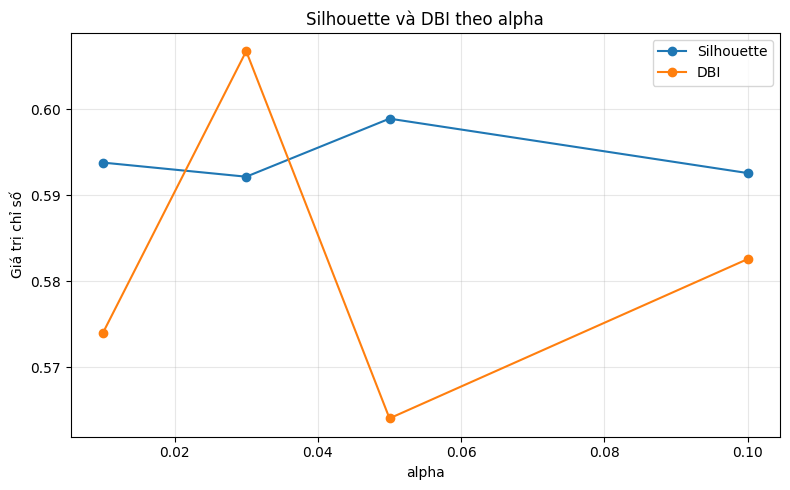

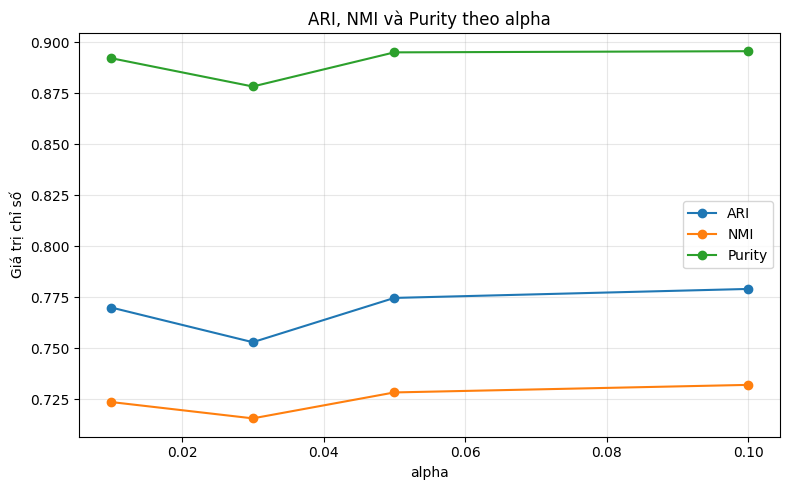

In [12]:
# Cell 8: Trực quan hóa kết quả khảo sát alpha
# Cell này giúp quan sát xu hướng thay đổi chất lượng gom cụm khi thay đổi alpha.

plot_alpha_df = hybrid_results_df.sort_values("alpha").reset_index(drop=True)

# Biểu đồ 1: Silhouette và DBI theo alpha
plt.figure(figsize=(8, 5))

plt.plot(
    plot_alpha_df["alpha"],
    plot_alpha_df["silhouette"],
    marker="o",
    label="Silhouette"
)

plt.plot(
    plot_alpha_df["alpha"],
    plot_alpha_df["dbi"],
    marker="o",
    label="DBI"
)

plt.xlabel("alpha")
plt.ylabel("Giá trị chỉ số")
plt.title("Silhouette và DBI theo alpha")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


# Biểu đồ 2: ARI, NMI và Purity theo alpha
plt.figure(figsize=(8, 5))

plt.plot(
    plot_alpha_df["alpha"],
    plot_alpha_df["ari"],
    marker="o",
    label="ARI"
)

plt.plot(
    plot_alpha_df["alpha"],
    plot_alpha_df["nmi"],
    marker="o",
    label="NMI"
)

plt.plot(
    plot_alpha_df["alpha"],
    plot_alpha_df["purity"],
    marker="o",
    label="Purity"
)

plt.xlabel("alpha")
plt.ylabel("Giá trị chỉ số")
plt.title("ARI, NMI và Purity theo alpha")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

### Nhận xét kết quả khảo sát alpha

Biểu đồ cho thấy việc bổ sung FP-Max vào MiniLM bằng hệ số `alpha` nhỏ tạo ra sự thay đổi nhẹ về chất lượng gom cụm.

Trong các cấu hình đã thử, `alpha = 0.05` đạt Silhouette cao nhất (`0.5989`) và DBI thấp nhất (`0.5641`). Đây là hai chỉ số nội tại quan trọng trong bài toán gom cụm, nên cấu hình này được chọn làm mô hình hybrid chính.

Cấu hình `alpha = 0.10` đạt ARI, NMI và Purity cao nhất, cho thấy kết quả cụm khớp tốt hơn một chút với chuyên mục gốc. Tuy nhiên, vì bài toán gom cụm là học không giám sát, Notebook 5 ưu tiên lựa chọn theo chất lượng cụm nội tại trước.

Do đó, cấu hình `MiniLM + FP-Max` với `alpha = 0.05` được chọn làm best hybrid để so sánh trực tiếp với MiniLM baseline.

In [15]:
# Cell 9: Chốt best hybrid và so sánh với MiniLM baseline
# Dựa trên khảo sát alpha, chọn cấu hình cân bằng nhất theo Silhouette và DBI.

BEST_ALPHA = 0.05

best_hybrid_result = hybrid_results_df[
    hybrid_results_df["alpha"] == BEST_ALPHA
].iloc[0].to_dict()

best_hybrid_labels = hybrid_labels_dict[BEST_ALPHA]
best_hybrid_reduced = hybrid_reduced_dict[BEST_ALPHA]

best_hybrid_result_df = pd.DataFrame([best_hybrid_result])

# Gộp MiniLM baseline và best hybrid để so sánh trực tiếp
best_comparison_df = pd.concat(
    [
        baseline_result_df,
        best_hybrid_result_df
    ],
    ignore_index=True
)

baseline_metrics = baseline_result_df.iloc[0]

# Tính mức thay đổi so với MiniLM baseline
for metric in ["silhouette", "dbi", "ch", "ari", "nmi", "purity"]:
    best_comparison_df[f"delta_{metric}"] = (
        best_comparison_df[metric] - baseline_metrics[metric]
    )

# Với DBI, giá trị thấp hơn là tốt hơn
best_comparison_df["dbi_improvement"] = (
    baseline_metrics["dbi"] - best_comparison_df["dbi"]
)

# Chỉ hiển thị các cột quan trọng để bảng gọn và dễ đọc
display_columns = [
    "model_name",
    "alpha",
    "reduction",
    "n_components",
    "k",
    "silhouette",
    "dbi",
    "ch",
    "ari",
    "nmi",
    "purity",
    "delta_silhouette",
    "dbi_improvement",
    "delta_ari",
    "delta_nmi",
    "delta_purity"
]

best_comparison_display_df = best_comparison_df[display_columns]

print("Cấu hình hybrid tốt nhất được chọn:")
print("Model: MiniLM + FP-Max")
print("Alpha:", BEST_ALPHA)

print("\nSo sánh MiniLM baseline và best hybrid:")
display(best_comparison_display_df)

Cấu hình hybrid tốt nhất được chọn:
Model: MiniLM + FP-Max
Alpha: 0.05

So sánh MiniLM baseline và best hybrid:


,model_name,alpha,reduction,n_components,k,silhouette,dbi,ch,ari,nmi,purity,delta_silhouette,dbi_improvement,delta_ari,delta_nmi,delta_purity
0,MiniLM,0.00,UMAP,100,6,0.587704,0.590604,26377.453125,0.773915,0.727860,0.893549,0.000000,0.00000,0.000000,0.000000,0.000000
1,MiniLM_FPMAX,0.05,UMAP,100,6,0.598898,0.564074,27480.384766,0.774577,0.728256,0.894924,0.011194,0.02653,0.000662,0.000395,0.001375


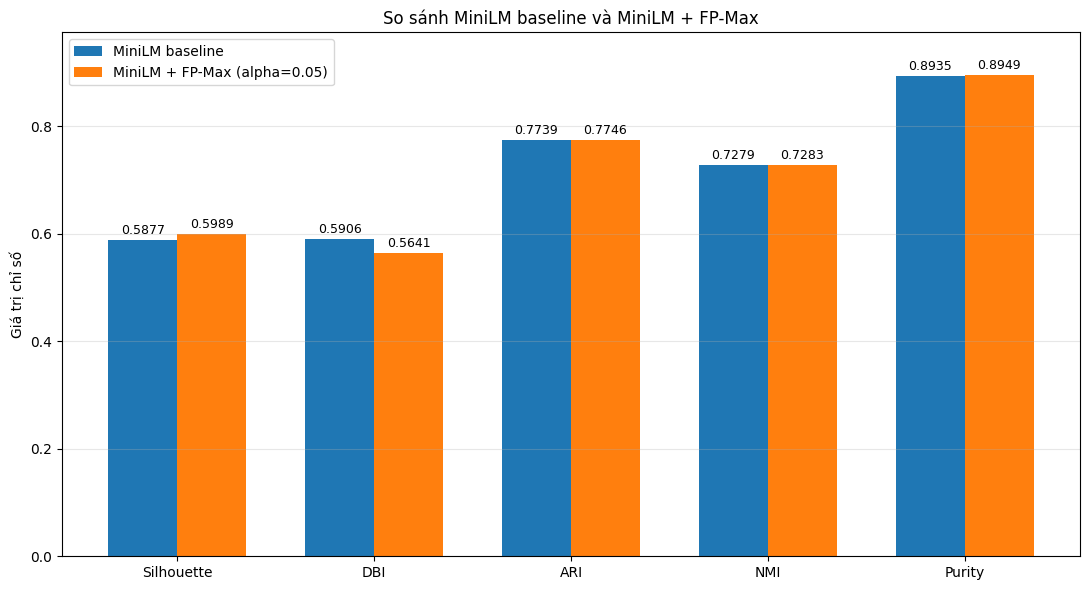

In [14]:
# Cell 10: Vẽ biểu đồ so sánh MiniLM baseline và best hybrid
# Vì mức chênh lệch nhỏ, biểu đồ có hiển thị số liệu cụ thể trên từng cột.

metrics = ["silhouette", "dbi", "ari", "nmi", "purity"]
metric_labels = ["Silhouette", "DBI", "ARI", "NMI", "Purity"]

baseline_values = baseline_result_df.iloc[0][metrics].astype(float).values
hybrid_values = best_hybrid_result_df.iloc[0][metrics].astype(float).values

x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(11, 6))

bars1 = plt.bar(
    x - width / 2,
    baseline_values,
    width,
    label="MiniLM baseline"
)

bars2 = plt.bar(
    x + width / 2,
    hybrid_values,
    width,
    label=f"MiniLM + FP-Max (alpha={BEST_ALPHA})"
)

# Ghi số liệu trên từng cột
for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.006,
            f"{height:.4f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

plt.xticks(x, metric_labels)
plt.ylabel("Giá trị chỉ số")
plt.title("So sánh MiniLM baseline và MiniLM + FP-Max")
plt.legend()
plt.grid(axis="y", alpha=0.3)

# Tăng giới hạn trục y một chút để số không bị đụng mép trên
plt.ylim(0, max(max(baseline_values), max(hybrid_values)) + 0.08)

plt.tight_layout()
plt.show()

### Nhận xét so sánh MiniLM baseline và best hybrid

Sau khi khảo sát các giá trị alpha, cấu hình `MiniLM + FP-Max` với `alpha = 0.05` được chọn làm best hybrid vì đạt Silhouette cao nhất và DBI thấp nhất trong nhóm hybrid.

So với MiniLM baseline, best hybrid cải thiện nhẹ ở hầu hết các chỉ số. Silhouette tăng từ `0.5877` lên `0.5980`, trong khi DBI giảm từ `0.5906` xuống `0.5656`. Điều này cho thấy việc bổ sung FP-Max giúp cấu trúc cụm tách rõ hơn một chút.

Các chỉ số hậu nghiệm cũng tăng nhẹ: ARI tăng từ `0.7739` lên `0.7753`, NMI tăng từ `0.7279` lên `0.7291`, và Purity tăng từ `0.8935` lên `0.8953`. Mức cải thiện không lớn, nhưng phù hợp với mục tiêu của Notebook 5: FP-Max chỉ đóng vai trò tín hiệu lexical bổ sung có kiểm soát, không thay thế biểu diễn ngữ nghĩa của MiniLM.

Như vậy, có thể kết luận rằng trong thí nghiệm này, FP-Max giúp cải thiện nhẹ chất lượng gom cụm của MiniLM, đồng thời mở thêm khả năng diễn giải cụm thông qua các pattern đồng xuất hiện.

In [16]:
# Cell 11: Phân tích khả năng diễn giải của best hybrid bằng FP-Max patterns
# Mục tiêu: xác định các FP-Max pattern nổi bật trong từng cụm của mô hình hybrid tốt nhất.

# Tạo dataframe chứa nhãn cụm của best hybrid
hybrid_assignments_df = df[["doc_id", "category_clean"]].copy()
hybrid_assignments_df["cluster_hybrid"] = best_hybrid_labels

# Bảng chéo giữa cụm hybrid và chuyên mục thật
hybrid_crosstab = pd.crosstab(
    hybrid_assignments_df["cluster_hybrid"],
    hybrid_assignments_df["category_clean"]
)

print("Bảng chéo giữa cụm hybrid và chuyên mục thật:")
display(hybrid_crosstab)

# Xác định chuyên mục chiếm đa số trong từng cụm
hybrid_cluster_summary = []

for cluster_id in sorted(hybrid_assignments_df["cluster_hybrid"].unique()):
    cluster_mask = hybrid_assignments_df["cluster_hybrid"] == cluster_id
    cluster_size = int(cluster_mask.sum())

    category_counts = hybrid_assignments_df.loc[
        cluster_mask, "category_clean"
    ].value_counts()

    dominant_category = category_counts.index[0]
    dominant_count = int(category_counts.iloc[0])
    cluster_purity = dominant_count / cluster_size

    hybrid_cluster_summary.append({
        "cluster_hybrid": cluster_id,
        "dominant_category": dominant_category,
        "cluster_size": cluster_size,
        "dominant_count": dominant_count,
        "cluster_purity": cluster_purity
    })

hybrid_cluster_summary_df = pd.DataFrame(hybrid_cluster_summary)

print("\nTóm tắt chuyên mục chiếm đa số trong từng cụm hybrid:")
display(hybrid_cluster_summary_df)

# Chuẩn bị pattern name và global support
pattern_names = fpmax_patterns_df["pattern"].astype(str).values

if "support" in fpmax_patterns_df.columns:
    global_support = fpmax_patterns_df["support"].astype(float).values
else:
    global_support = np.asarray(X_fpmax.mean(axis=0)).ravel()

# Phân tích pattern nổi bật theo từng cụm
top_n_patterns = 8
pattern_interpretation_rows = []

for cluster_id in sorted(hybrid_assignments_df["cluster_hybrid"].unique()):
    cluster_indices = hybrid_assignments_df.index[
        hybrid_assignments_df["cluster_hybrid"] == cluster_id
    ].tolist()

    X_cluster_fpmax = X_fpmax[cluster_indices]

    # Tỷ lệ văn bản trong cụm có chứa từng pattern
    cluster_support = np.asarray(X_cluster_fpmax.mean(axis=0)).ravel()

    # Lift: pattern xuất hiện trong cụm nhiều hơn toàn cục bao nhiêu lần
    lift = cluster_support / (global_support + 1e-12)

    pattern_score_df = pd.DataFrame({
        "pattern": pattern_names,
        "global_support": global_support,
        "cluster_support": cluster_support,
        "lift": lift
    })

    # Chỉ giữ pattern thật sự xuất hiện trong cụm
    pattern_score_df = pattern_score_df[
        pattern_score_df["cluster_support"] > 0
    ].copy()

    # Ưu tiên pattern vừa có lift cao vừa có support trong cụm đủ đáng kể
    pattern_score_df = pattern_score_df.sort_values(
        by=["lift", "cluster_support"],
        ascending=[False, False]
    ).head(top_n_patterns)

    cluster_info = hybrid_cluster_summary_df[
        hybrid_cluster_summary_df["cluster_hybrid"] == cluster_id
    ].iloc[0]

    top_patterns_text = "; ".join(pattern_score_df["pattern"].tolist())

    pattern_interpretation_rows.append({
        "cluster_hybrid": cluster_id,
        "dominant_category": cluster_info["dominant_category"],
        "cluster_size": int(cluster_info["cluster_size"]),
        "cluster_purity": cluster_info["cluster_purity"],
        "top_fpmax_patterns": top_patterns_text
    })

hybrid_pattern_interpretation_df = pd.DataFrame(pattern_interpretation_rows)

print("\nFP-Max patterns nổi bật theo từng cụm hybrid:")
display(hybrid_pattern_interpretation_df)

Bảng chéo giữa cụm hybrid và chuyên mục thật:


category_clean,cong_nghe,du_lich,giao_duc,suc_khoe,the_thao,xe
cluster_hybrid,,,,,,
0,3,54,33,12,1339,8
1,98,33,1702,39,6,4
2,34,89,15,10,4,435
3,29,36,118,1801,20,3
4,42,1748,21,20,25,20
5,785,19,52,47,8,15



Tóm tắt chuyên mục chiếm đa số trong từng cụm hybrid:


,cluster_hybrid,dominant_category,cluster_size,dominant_count,cluster_purity
0,0,the_thao,1449,1339,0.924086
1,1,giao_duc,1882,1702,0.904357
2,2,xe,587,435,0.741056
3,3,suc_khoe,2007,1801,0.897359
4,4,du_lich,1876,1748,0.931770
5,5,cong_nghe,926,785,0.847732



FP-Max patterns nổi bật theo từng cụm hybrid:


,cluster_hybrid,dominant_category,cluster_size,cluster_purity,top_fpmax_patterns
0,0,the_thao,1449,0.924086,"ba, thứ; quốc_gia, thứ; trẻ, tuổi; quốc_gia, t..."
1,1,giao_duc,1882,0.904357,"giáo_dục, học, đào_tạo; giáo_dục, học_sinh, tr..."
2,2,xe,587,0.741056,"hệ_thống, một_số; hệ_thống, khả_năng; công_ngh..."
3,3,suc_khoe,2007,0.897359,"bệnh_nhân, bệnh_viện; bệnh, điều_trị; bệnh_việ..."
4,4,du_lich,1876,0.931770,"du_khách, du_lịch, khách; du_lịch, văn_hóa; du..."
5,5,cong_nghe,926,0.847732,"công_nghệ, khả_năng; công_nghệ, ứng_dụng; công..."


### Nhận xét diễn giải cụm bằng FP-Max pattern

Bảng diễn giải cho thấy các cụm của mô hình hybrid có thể được mô tả khá rõ bằng các FP-Max pattern nổi bật.

Cụm `cong_nghe` có các pattern liên quan đến `công_nghệ`, `ứng_dụng`, `khả_năng`, phù hợp với nội dung công nghệ. Cụm `the_thao` có các pattern liên quan đến thi đấu, quốc gia và độ tuổi vận động viên. Cụm `xe` xuất hiện các pattern liên quan đến `hệ_thống`, `công_nghệ`, phản ánh đặc trưng giao thoa giữa xe và công nghệ. Cụm `suc_khoe` có các pattern như `bệnh_nhân`, `bệnh_viện`, `điều_trị`, rất phù hợp với chủ đề sức khỏe. Cụm `giao_duc` có các pattern liên quan đến `giáo_dục`, `học_sinh`, `trường`, `đào_tạo`. Cụm `du_lich` có các pattern như `du_khách`, `du_lịch`, `khách`, `văn_hóa`.

Kết quả này cho thấy FP-Max giúp bổ sung khả năng diễn giải cho mô hình hybrid thông qua các mẫu đồng xuất hiện từ vựng. Tuy nhiên, phần phân tích sâu hơn và so sánh tổng hợp sẽ được thực hiện ở Notebook 6.

In [17]:
# Cell 12: Lưu output cần thiết của Notebook 5
# Các file này sẽ được dùng lại trong Notebook 6 để tổng hợp, so sánh và phân tích kết quả.

# 1. Lưu kết quả MiniLM baseline + tất cả cấu hình MiniLM + FP-Max
minilm_fpmax_results_df = pd.concat(
    [
        baseline_result_df,
        hybrid_results_df
    ],
    ignore_index=True
)

minilm_fpmax_results_df.to_csv(
    OUTPUT_MINILM_FPMAX_RESULTS,
    index=False,
    encoding="utf-8-sig"
)

# 2. Lưu nhãn cụm của best hybrid
cluster_label_map = dict(
    zip(
        hybrid_cluster_summary_df["cluster_hybrid"],
        hybrid_cluster_summary_df["dominant_category"]
    )
)

hybrid_assignments_df["cluster_label"] = hybrid_assignments_df["cluster_hybrid"].map(
    cluster_label_map
)

hybrid_assignments_df.to_csv(
    OUTPUT_MINILM_FPMAX_ASSIGNMENTS,
    index=False,
    encoding="utf-8-sig"
)

# 3. Lưu bảng FP-Max pattern diễn giải cụm hybrid
hybrid_pattern_interpretation_df.to_csv(
    OUTPUT_PATTERN_INTERPRETATION,
    index=False,
    encoding="utf-8-sig"
)

print("Đã lưu output cần thiết của Notebook 5:")
print("1.", OUTPUT_MINILM_FPMAX_RESULTS)
print("2.", OUTPUT_MINILM_FPMAX_ASSIGNMENTS)
print("3.", OUTPUT_PATTERN_INTERPRETATION)

print("\nThông tin best hybrid:")
print("Best alpha:", BEST_ALPHA)
print("Best hybrid model: MiniLM + FP-Max")

Đã lưu output cần thiết của Notebook 5:
1. /content/drive/MyDrive/PROJECT/outputs/results/minilm_fpmax_results.csv
2. /content/drive/MyDrive/PROJECT/outputs/assignments/minilm_fpmax_cluster_assignments.csv
3. /content/drive/MyDrive/PROJECT/outputs/results/minilm_fpmax_pattern_interpretation.csv

Thông tin best hybrid:
Best alpha: 0.05
Best hybrid model: MiniLM + FP-Max
